<a href="https://colab.research.google.com/github/iav2002/AppliedDeepLearning/blob/main/PArt2_KernelActivation_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2, Notebook 4, Kernel Size and Activation Variations

In this notebook I investigate two design choices on top of the baseline CNN from notebook 3, the convolution kernel size and the activation function. I focus on the regression task (predicting exact age) because the baseline trained for a full 20 epochs without overfitting, which gives a clean signal of how each variant changes feature extraction.

The baseline uses 3x3 kernels and ReLU throughout, so that is the reference point every variant has to beat.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/AppliedDL/face_age.zip" /content/
!cp -r "/content/drive/MyDrive/Colab Notebooks/AppliedDL/data_splits" /content/
!unzip -q /content/face_age.zip -d /content/

## 2. Imports


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path

# device, use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

device: cuda
gpu: NVIDIA L4


## 3. Dataset class

Same `FaceAgeDataset` as the baseline. One class, `task` argument switches between regression (float age) and classification (category index). The CSVs hold relative paths so we prepend `/content/`.

In [4]:
CATEGORIES = ["infant", "child", "teen", "youth", "mid", "mature", "senior"]
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}


class FaceAgeDataset(Dataset):
    def __init__(self, csv_path, task, transform=None):
        # task is either "regression" or "classification"
        self.df = pd.read_csv(csv_path)
        self.task = task
        self.transform = transform
        # build full paths once at init so __getitem__ is fast
        self.paths = ["/content/" + p for p in self.df["path"]]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.task == "regression":
            label = torch.tensor(self.df.iloc[idx]["age"], dtype=torch.float32)
        else:
            cat = self.df.iloc[idx]["age_category"]
            label = torch.tensor(CAT_TO_IDX[cat], dtype=torch.long)

        return img, label

## 4. Transforms and dataloaders

Same minimal transform pipeline as the baseline, just `ToTensor` and ImageNet normalization.

Two loaders, train and val, regression task.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds_reg = FaceAgeDataset("/content/data_splits/train.csv", "regression", transform)
val_ds_reg   = FaceAgeDataset("/content/data_splits/val.csv",   "regression", transform)

BATCH_SIZE = 64

train_loader_reg = DataLoader(train_ds_reg, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True, persistent_workers=True)
val_loader_reg   = DataLoader(val_ds_reg,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True, persistent_workers=True)

print(f"train: {len(train_ds_reg)}    val: {len(val_ds_reg)}")

train: 7320    val: 1464


## 5. Parameterised CNN

To run kernel and activation variations cleanly, the same model takes both as constructor arguments. Defaults match the baseline (3x3 kernels, ReLU), so building it with no args reproduces notebook 3's network. Padding is computed as `kernel_size // 2` so spatial dimensions are preserved across kernel sizes, which means the FC layer geometry stays the same between variants.

A single activation instance is reused across layers. This is safe because the activations we test are stateless. PReLU has learnable parameters per layer and would need one instance per layer, but we won't be using it.

In [6]:
class VariantCNN(nn.Module):
    def __init__(self, num_outputs, kernel_size=3, activation=nn.ReLU):
        super().__init__()
        # pad chosen so output spatial size matches input, keeps FC geometry fixed
        pad = kernel_size // 2

        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_size, padding=pad)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=pad)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=pad)
        self.pool3 = nn.MaxPool2d(2)

        # 200 -> 100 -> 50 -> 25 after three 2x2 pools
        self.fc1 = nn.Linear(128 * 25 * 25, 128)
        self.fc2 = nn.Linear(128, num_outputs)

        # one shared instance, all the activations we test are stateless so reusing is fine
        self.act = activation()

    def forward(self, x):
        x = self.pool1(self.act(self.conv1(x)))
        x = self.pool2(self.act(self.conv2(x)))
        x = self.pool3(self.act(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x


# sanity check, build with defaults (this should equal the baseline)
model = VariantCNN(num_outputs=1).to(device)
dummy = torch.randn(2, 3, 200, 200).to(device)
out = model(dummy)
print(f"output shape: {out.shape}")
print(f"total parameters: {sum(p.numel() for p in model.parameters()):,}")

output shape: torch.Size([2, 1])
total parameters: 10,333,505


## 6. Train and eval functions

Same `train_one_epoch` and `evaluate` as the baseline. They're generic over both tasks, the caller passes the loss function and the task string. Reusing them unchanged keeps the variant comparison fair, any difference in results is down to the model, not the training code.

In [7]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0
    n_samples = 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        out = model(imgs)
        # for regression, model outputs [B,1], squeeze to match labels [B]
        if out.shape[-1] == 1:
            out = out.squeeze(-1)
        loss = loss_fn(out, lbls)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        n_samples += imgs.size(0)

    return total_loss / n_samples


def evaluate(model, loader, loss_fn, task):
    model.eval()
    total_loss = 0
    n_samples = 0
    correct = 0
    abs_error_sum = 0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            if out.shape[-1] == 1:
                out = out.squeeze(-1)
            loss = loss_fn(out, lbls)

            total_loss += loss.item() * imgs.size(0)
            n_samples += imgs.size(0)

            if task == "regression":
                abs_error_sum += (out - lbls).abs().sum().item()
            else:
                preds = out.argmax(dim=1)
                correct += (preds == lbls).sum().item()

    avg_loss = total_loss / n_samples
    if task == "regression":
        metric = abs_error_sum / n_samples
    else:
        metric = correct / n_samples

    return avg_loss, metric

## 7. Variant runner

Wraps the training loop so each variant trains the same way. Returns best metric, best weights, and full history. Patience 5, Adam, max 20 epochs. `min_or_max` direction handled internally so the same runner works for MAE (lower better) and accuracy (higher better).

In [8]:
def run_variant(model, train_loader, val_loader, loss_fn, task,
                max_epochs=20, patience=5, lr=1e-3, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # opposite directions for the two tasks
    if task == "regression":
        best_metric = float("inf")
        better = lambda new, best: new < best
    else:
        best_metric = -float("inf")
        better = lambda new, best: new > best

    history = {"train_loss": [], "val_loss": [], "val_metric": []}
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_metric = evaluate(model, val_loader, loss_fn, task)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_metric"].append(val_metric)

        if better(val_metric, best_metric):
            best_metric = val_metric
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            marker = " (best)"
        else:
            epochs_no_improve += 1
            marker = ""

        if verbose:
            print(f"  epoch {epoch:2d}    train_loss {train_loss:7.4f}    "
                  f"val_loss {val_loss:7.4f}    val_metric {val_metric:.4f}{marker}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"  stopped early at epoch {epoch}, no improvement for {patience} epochs")
            break

    # restore best weights before returning
    model.load_state_dict(best_state)
    return {"best_metric": best_metric, "best_state": best_state, "history": history}

## 8. Variants

Six variants. The baseline (3x3, ReLU) is rerun inside this notebook so all variants train under the same session conditions, fairer than comparing to notebook 3's numbers across sessions.

- Kernel axis (activation fixed to ReLU), 3x3, 5x5, 7x7
- Activation axis (kernel fixed to 3x3), ReLU, LeakyReLU, GELU, ELU

In [9]:
variants = [
    {"name": "baseline",  "kernel": 3, "act": nn.ReLU},
    {"name": "k5",        "kernel": 5, "act": nn.ReLU},
    {"name": "k7",        "kernel": 7, "act": nn.ReLU},
    {"name": "leakyrelu", "kernel": 3, "act": nn.LeakyReLU},
    {"name": "gelu",      "kernel": 3, "act": nn.GELU},
]

for v in variants:
    print(f"{v['name']:12s}  kernel {v['kernel']}  act {v['act'].__name__}")

baseline      kernel 3  act ReLU
k5            kernel 5  act ReLU
k7            kernel 7  act ReLU
leakyrelu     kernel 3  act LeakyReLU
gelu          kernel 3  act GELU


## 9. Regression sweep

Train all five variants on the regression task. MSE loss, MAE tracked as the interpretable metric. Each variant trains from scratch, results collected in `results_reg`. Classification is left out of this notebook deliberately, the baseline regression curve trained cleanly across 20 epochs which makes it the better setting to read variant effects from, while classification overfit too early to compare variants fairly.

In [10]:
import time

results_reg = {}
loss_fn = nn.MSELoss()

for v in variants:
    print(f"\n=== {v['name']} (kernel {v['kernel']}, act {v['act'].__name__}) ===")
    t0 = time.time()

    model = VariantCNN(num_outputs=1, kernel_size=v["kernel"], activation=v["act"]).to(device)
    result = run_variant(model, train_loader_reg, val_loader_reg, loss_fn, "regression")

    elapsed = time.time() - t0
    results_reg[v["name"]] = result
    print(f"  best val MAE {result['best_metric']:.3f}    time {elapsed:.0f}s")


=== baseline (kernel 3, act ReLU) ===
  epoch  1    train_loss 440.1097    val_loss 233.9895    val_metric 11.1413 (best)
  epoch  2    train_loss 222.4265    val_loss 204.7878    val_metric 9.9273 (best)
  epoch  3    train_loss 179.5305    val_loss 156.2526    val_metric 8.9889 (best)
  epoch  4    train_loss 143.6773    val_loss 141.8643    val_metric 8.5725 (best)
  epoch  5    train_loss 120.7692    val_loss 125.7640    val_metric 7.9003 (best)
  epoch  6    train_loss 95.5645    val_loss 129.7740    val_metric 8.1543
  epoch  7    train_loss 75.9575    val_loss 105.1873    val_metric 7.0094 (best)
  epoch  8    train_loss 71.2091    val_loss 125.1200    val_metric 8.0701
  epoch  9    train_loss 53.9431    val_loss 104.2126    val_metric 7.2310
  epoch 10    train_loss 43.0493    val_loss 150.4717    val_metric 8.7199
  epoch 11    train_loss 37.8980    val_loss 103.3166    val_metric 6.9317 (best)
  epoch 12    train_loss 27.9185    val_loss 103.9230    val_metric 6.9758
  epoc

## 10. Results

variant        best MAE  epoch
baseline          6.932     11
k5                6.324     19
k7                7.418     11
leakyrelu         6.645     15
gelu              6.879     17


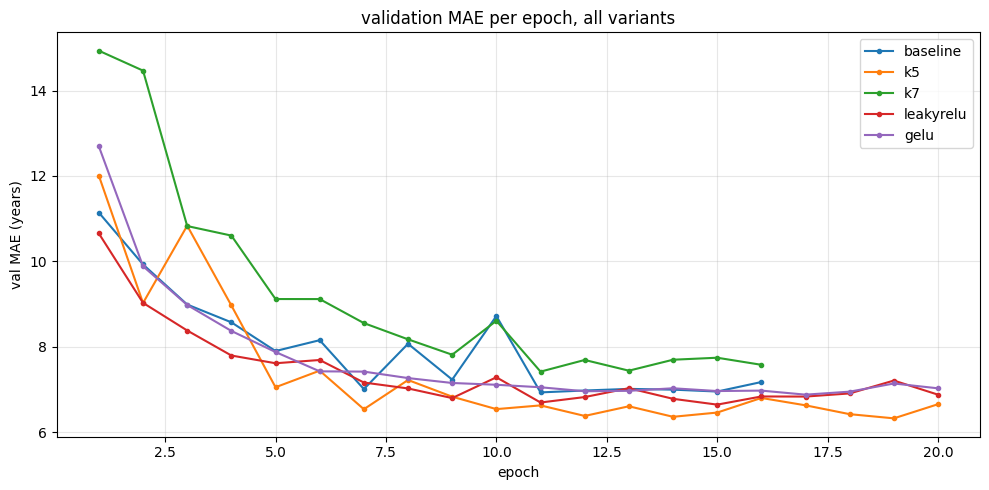

In [11]:
import matplotlib.pyplot as plt

# summary table
print(f"{'variant':12s}  {'best MAE':>9s}  {'epoch':>5s}")
for name, r in results_reg.items():
    best_ep = r["history"]["val_metric"].index(r["best_metric"]) + 1
    print(f"{name:12s}  {r['best_metric']:9.3f}  {best_ep:5d}")

# val MAE curves overlaid
fig, ax = plt.subplots(figsize=(10, 5))
for name, r in results_reg.items():
    epochs = range(1, len(r["history"]["val_metric"]) + 1)
    ax.plot(epochs, r["history"]["val_metric"], label=name, marker="o", markersize=3)

ax.set_xlabel("epoch")
ax.set_ylabel("val MAE (years)")
ax.set_title("validation MAE per epoch, all variants")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Save best variant

k5 with ReLU was the winner at MAE 6.32, saved with the same metadata pattern as the baseline so the demo notebook can load it later.

In [12]:
import os
os.makedirs("/content/models", exist_ok=True)

# k5 + ReLU was the best, save it as a candidate for the demo
best_name = "k5"
best_result = results_reg[best_name]

torch.save({
    "state_dict": best_result["best_state"],
    "task": "regression",
    "arch": "VariantCNN",
    "kernel_size": 5,
    "activation": "ReLU",
    "img_size": 200,
    "channels": 3,
    "val_mae": best_result["best_metric"],
}, "/content/models/regression_k5_relu.pt")

# mirror to drive so it survives session ending
!mkdir -p "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models"
!cp /content/models/regression_k5_relu.pt "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models/"

print("saved")
!ls -lh "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models/"

saved
total 119M
-rw------- 1 root root 40M May 11 15:43 classification_baseline.pt
-rw------- 1 root root 40M May 11 15:43 regression_baseline.pt
-rw------- 1 root root 41M May 11 16:05 regression_k5_relu.pt
